# Grid-operator power-limit signals

The five operator signals in `data/operator_signals/` as a single small-multiples figure
for the thesis: one panel per profile, arranged in **2 columns**, sized for a full A4 text
width, with every plateau labelled by its power limit in kW.

Each CSV holds *sparse step-change events*, not a sampled time series. `OperatorEnergyControl`
keys every row by its time of day (`seconds_from_midnight // control_step`), holds the last
value until the next event, and repeats the profile every simulated day — see
`adv_building_gym/components/statesources/outer/operator_energy_control.py`
(`_post_load_data_processing`, `update_state`). The dates in the `start` column are therefore
irrelevant; only the clock time is read. A profile is consequently drawn as a
**piecewise-constant (hold-last) step over 00:00-24:00**, never as an interpolated line.

Outputs, both written next to this notebook:

- `operator_signals.pdf` — matplotlib preview of the layout,
- `operator_signals.tex` — native TikZ/pgfplots `groupplot` for the thesis.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Walk up to the repository root so the notebook runs from any working directory.
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "data" / "operator_signals").is_dir())
SIGNAL_DIR = REPO_ROOT / "data" / "operator_signals"
OUT_DIR = Path.cwd()

# Order follows configs/schedules/data/{train,eval}.yaml.
PROFILE_FILES = [
    "op_constant_20kW.csv",
    "op_daytime_boost.csv",
    "op_evening_peak_relief.csv",
    "op_eval_night_charge.csv",
    "op_eval_two_dip.csv",
]

VALUE_COL = "max_power_kW"
HOURS_PER_DAY = 24
N_COLS = 2

# --- Page geometry -------------------------------------------------------------------
# A4 (21 cm) with standard 2.5 cm margins leaves a 16 cm text block (\linewidth = 455.2 pt
# in an 11 pt article). With the pgfplots default (`scale only axis=false`) `width` is the
# TOTAL width of one panel including its tick labels and axis labels, so the two-column
# group measures 2 * PANEL_WIDTH_FRACTION * \linewidth + ~15 pt of separation. Measured by
# compiling the emitted figure at three fractions: 0.40 -> 378.9 pt, 0.45 -> 424.4 pt,
# 0.50 -> 470.0 pt. 0.48 therefore fills 451.8 pt, ~99 % of the text block, without
# overrunning it. The matplotlib preview mirrors the same 16 cm in inches.
TEXT_WIDTH_CM = 16.0
PANEL_WIDTH_FRACTION = 0.48   # of \linewidth, per panel (incl. its labels)
PANEL_HEIGHT_CM = 2.8
H_SEP_CM = 1.5
# V_SEP_CM has to clear two stacked texts between rows: the x label under one panel and
# the title of the panel below it.
# A short panel has room for few y ticks and for a y label no longer than the axis itself,
# so the ticks are spaced 20 kW apart and the label is kept to two words.
Y_TICK_STEP_KW = 20
Y_LABEL = "Limit (kW)"
X_LABEL = "Time of day (h)"
V_SEP_CM = 2.0

# Palette shared with the TikZ export below, so preview and thesis figure cannot drift apart.
# Same ink as thesis_eval/1_intro_figs/ev_capacities/EV_battery_analysis.ipynb.
BLUE = "#2a78d6"    # step line
GRID = "#e1e0d9"    # y grid
TICK = "#3B3B3B"    # tick labels and plateau labels
INK = "#0b0b0b"     # axis labels


def load_profile(path: Path) -> pd.DataFrame:
    """Read one signal CSV and add the event time of day in hours."""
    df = pd.read_csv(path, parse_dates=["start"])
    df["hour"] = (df["start"].dt.hour
                  + df["start"].dt.minute / 60.0
                  + df["start"].dt.second / 3600.0)
    return df.sort_values("hour").reset_index(drop=True)


profiles = {path.stem: load_profile(SIGNAL_DIR / path.name)
            for path in (SIGNAL_DIR / f for f in PROFILE_FILES)}

for name, df in profiles.items():
    events = ", ".join(f"{h:05.2f}h→{v:g}kW" for h, v in zip(df["hour"], df[VALUE_COL]))
    print(f"{name:<24} {len(df)} events   {events}")


op_constant_20kW         1 events   00.00h→20kW
op_daytime_boost         6 events   00.00h→35kW, 06.00h→20kW, 08.50h→30kW, 16.00h→20kW, 22.50h→30kW, 23.25h→35kW
op_evening_peak_relief   5 events   00.00h→30kW, 06.00h→20kW, 17.00h→16kW, 21.00h→25kW, 22.00h→30kW
op_eval_night_charge     3 events   00.00h→35kW, 06.00h→20kW, 22.00h→40kW
op_eval_two_dip          5 events   00.00h→35kW, 08.00h→18kW, 11.00h→25kW, 18.00h→18kW, 21.50h→30kW


## Step expansion

The event rows are turned into `(hour, kW)` corner points and the last plateau is closed at
24:00, which is what the environment actually delivers: the held value only changes when an
event fires, and the profile restarts at midnight.

`plateaus()` derives the constant sections from the same events — one `(start, end, kW)` per
held level — so every section can be labelled with its limit (six of them for
`op_daytime_boost`).


In [2]:
def step_coordinates(df: pd.DataFrame) -> tuple[list[float], list[float]]:
    """Hold-last corner points of one profile, closed at 24:00 (matplotlib `where="post"`)."""
    hours = df["hour"].tolist() + [float(HOURS_PER_DAY)]
    levels = df[VALUE_COL].tolist() + [float(df[VALUE_COL].iloc[-1])]
    return hours, levels


def plateaus(df: pd.DataFrame) -> list[tuple[float, float, float]]:
    """Constant sections as (start_hour, end_hour, kW); the last one runs to midnight."""
    starts = df["hour"].tolist()
    ends = starts[1:] + [float(HOURS_PER_DAY)]
    return list(zip(starts, ends, df[VALUE_COL].tolist()))


steps = {name: step_coordinates(df) for name, df in profiles.items()}
sections = {name: plateaus(df) for name, df in profiles.items()}

# Shared y-range so panel heights are comparable across profiles; the headroom keeps the
# labels of the highest plateaus inside the axis.
Y_MAX = max(max(levels) for _, levels in steps.values()) * 1.25
n_plots = len(steps)
n_rows = -(-n_plots // N_COLS)   # ceil

# A label centred on a section at the very edge of the axis would stick out, so the
# outermost ones are anchored to the axis edge instead of to the section centre.
EDGE_MARGIN_HOURS = 1.5


def label_anchor(start: float, end: float) -> tuple[float, str]:
    """(x position, anchor) that keeps a section label inside the axis."""
    centre = (start + end) / 2.0
    if centre < EDGE_MARGIN_HOURS:
        return start, "left"
    if centre > HOURS_PER_DAY - EDGE_MARGIN_HOURS:
        return end, "right"
    return centre, "center"


for name, secs in sections.items():
    print(f"{name:<24} {len(secs)} sections   " +
          ", ".join(f"{s:g}-{e:g}h:{v:g}kW" for s, e, v in secs))


op_constant_20kW         1 sections   0-24h:20kW
op_daytime_boost         6 sections   0-6h:35kW, 6-8.5h:20kW, 8.5-16h:30kW, 16-22.5h:20kW, 22.5-23.25h:30kW, 23.25-24h:35kW
op_evening_peak_relief   5 sections   0-6h:30kW, 6-17h:20kW, 17-21h:16kW, 21-22h:25kW, 22-24h:30kW
op_eval_night_charge     3 sections   0-6h:35kW, 6-22h:20kW, 22-24h:40kW
op_eval_two_dip          5 sections   0-8h:35kW, 8-11h:18kW, 11-18h:25kW, 18-21.5h:18kW, 21.5-24h:30kW


## Preview (matplotlib)

The same grid the TikZ export produces: 2 columns at A4 text width, shared axes, y label on
the left column, a time-of-day axis under every panel, and the kW value printed over every
constant section.


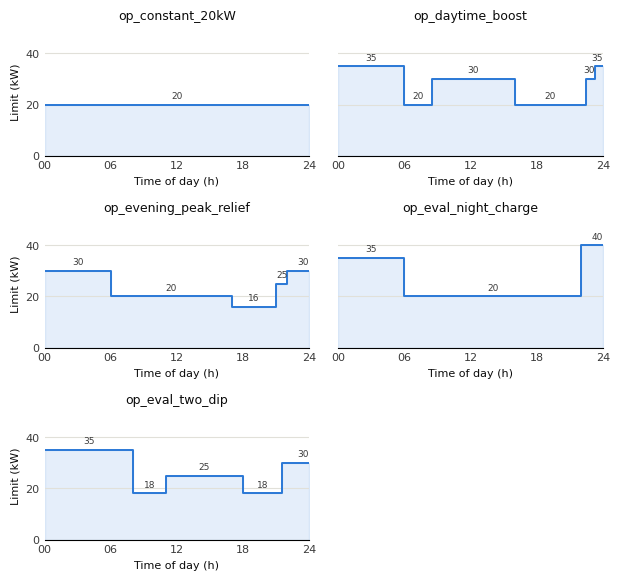

In [3]:
CM_PER_INCH = 2.54
fig_width_in = TEXT_WIDTH_CM / CM_PER_INCH
fig_height_in = (n_rows * (PANEL_HEIGHT_CM + V_SEP_CM) + 0.6) / CM_PER_INCH

# sharex=False: every panel prints its own time-of-day axis.
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(fig_width_in, fig_height_in),
                         sharex=False, sharey=True)

for idx, (name, (hours, levels)) in enumerate(steps.items()):
    ax = axes.flat[idx]
    ax.step(hours, levels, where="post", color=BLUE, linewidth=1.4)
    ax.fill_between(hours, levels, step="post", color=BLUE, alpha=0.12)

    # kW value over every constant section.
    for start, end, level in sections[name]:
        x_pos, anchor = label_anchor(start, end)
        ax.annotate(f"{level:g}", xy=(x_pos, level), xytext=(0, 3),
                    textcoords="offset points", ha=anchor, va="bottom",
                    fontsize=6.5, color=TICK)

    ax.set_title(name, fontsize=9, color=INK, pad=6)
    ax.set_xlim(0, HOURS_PER_DAY)
    ax.set_ylim(0, Y_MAX)
    ax.set_yticks(range(0, int(Y_MAX) + 1, Y_TICK_STEP_KW))
    ax.set_xticks(range(0, HOURS_PER_DAY + 1, 6))
    ax.set_xticklabels([f"{h:02d}" for h in range(0, HOURS_PER_DAY + 1, 6)])
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", colors=TICK, labelsize=8, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

    ax.set_xlabel(X_LABEL, fontsize=8, color=INK)
    if idx % N_COLS == 0:
        ax.set_ylabel(Y_LABEL, fontsize=8, color=INK)

for empty_idx in range(n_plots, n_rows * N_COLS):
    axes.flat[empty_idx].set_visible(False)

fig.tight_layout()
fig.savefig(OUT_DIR / "operator_signals.pdf", bbox_inches="tight")
plt.show()


## TikZ / pgfplots export

The same figure as native LaTeX, so the thesis typesets it with the document font and vector
output instead of embedding a PDF. Coordinates, palette, section labels and grid layout come
from the cells above, so preview and export cannot drift apart.

Writes `operator_signals.tex`, a complete `figure` block, pulled in with

```latex
\usepackage{pgfplots}
\pgfplotsset{compat=1.18}
\usepgfplotslibrary{groupplots}
...
\input{operator_signals.tex}
```

`const plot` is the pgfplots equivalent of matplotlib's `where="post"`: it draws each level
flat up to the next coordinate instead of interpolating.
Link: https://tikz.dev/pgfplots/reference-plothandlers#const-plot


In [4]:
TIKZ_PATH = OUT_DIR / "operator_signals.tex"

X_TICKS = list(range(0, HOURS_PER_DAY + 1, 6))
XTICK = ",".join(str(h) for h in X_TICKS)
XTICKLABELS = ",".join(f"{{{h:02d}}}" for h in X_TICKS)
# matplotlib anchor names → TikZ node anchors (TikZ anchors the node at the given side).
TIKZ_ANCHOR = {"left": "south west", "center": "south", "right": "south east"}


def rgb_hex(colour: str) -> str:
    """'#2a78d6' -> '2A78D6' for pgfplots' \\definecolor{...}{HTML}{...}."""
    return colour.lstrip("#").upper()


def tex_escape(text: str) -> str:
    """Underscores in the file stems are the only LaTeX-special characters here."""
    return text.replace("_", r"\_")


group_plots = []
for idx, (name, (hours, levels)) in enumerate(steps.items()):
    coords = " ".join(f"({h:g},{v:g})" for h, v in zip(hours, levels))
    options = [f"title={{{tex_escape(name)}}}"]
    options.append(f"ylabel={{{Y_LABEL}}}" if idx % N_COLS == 0 else "ylabel={}")
    # Every panel prints its own time-of-day axis.
    options.append(f"xlabel={{{X_LABEL}}}")
    options.append(f"xticklabels={{{XTICKLABELS}}}")

    labels = "\n".join(
        f"        \\node[anchor={TIKZ_ANCHOR[anchor]}, font=\\tiny, color=opTick, yshift=1pt]"
        f" at (axis cs:{x_pos:g},{level:g}) {{{level:g}}};"
        for x_pos, anchor, level in (
            (*label_anchor(start, end), level) for start, end, level in sections[name]
        )
    )

    # Two plots per panel: `\closedcycle` closes the path down to the axis and would
    # stroke that closing path as well, boxing in the panel — so the filled area is drawn
    # without a pen and the step line is laid on top.
    group_plots.append(
        "      \\nextgroupplot[" + ", ".join(options) + "]\n"
        "        \\addplot[const plot, mark=none, draw=none, fill=opLine, fill opacity=0.12]\n"
        f"          coordinates {{{coords}}} \\closedcycle;\n"
        "        \\addplot[const plot, mark=none, draw=opLine, line width=1pt]\n"
        f"          coordinates {{{coords}}};\n"
        f"{labels}"
    )

tikz = rf"""% Grid-operator power-limit signals from data/operator_signals/.
% Generated by thesis_eval/1_intro_figs/operator_signals/operator_signals.ipynb — do not edit.
% Sized for a {TEXT_WIDTH_CM:g}cm text block (A4, 2.5cm margins); widths follow \linewidth.
% Preamble: \usepackage{{pgfplots}} \pgfplotsset{{compat=1.18}} \usepgfplotslibrary{{groupplots}}
\definecolor{{opLine}}{{HTML}}{{{rgb_hex(BLUE)}}}
\definecolor{{opGrid}}{{HTML}}{{{rgb_hex(GRID)}}}
\definecolor{{opTick}}{{HTML}}{{{rgb_hex(TICK)}}}

\begin{{figure}}[!t]
  \centering
  \begin{{tikzpicture}}
    \begin{{groupplot}}[
      group style={{
        group size={N_COLS} by {n_rows},
        horizontal sep={H_SEP_CM:g}cm, vertical sep={V_SEP_CM:g}cm,
      }},
      width={PANEL_WIDTH_FRACTION:g}\linewidth, height={PANEL_HEIGHT_CM:g}cm,
      xmin=0, xmax={HOURS_PER_DAY},
      ymin=0, ymax={Y_MAX:.0f},
      % A section label sitting on the highest plateau reaches past ymax and would be cut
      % off by the axis clip path; no plot data leaves the limits, so clipping is not needed.
      clip=false,
      xtick={{{XTICK}}},
      ytick={{0,{Y_TICK_STEP_KW},...,{Y_MAX:.0f}}},
      ymajorgrids=true, xmajorgrids=false,
      grid style={{opGrid, line width=0.8pt}},
      axis x line*=bottom, axis y line*=left,
      y axis line style={{draw=none}},
      major tick style={{draw=none}},
      tick label style={{font=\footnotesize, color=opTick}},
      label style={{font=\footnotesize}},
      title style={{font=\footnotesize, yshift=-2pt}},
    ]
{chr(10).join(group_plots)}
    \end{{groupplot}}
  \end{{tikzpicture}}
  \caption{{The {n_plots} grid-operator power-limit signals, one panel per profile. Each is a
  sequence of step changes keyed by time of day; the limit holds its last value until the next
  change and the profile repeats every day. The number over each section is that section's
  limit in kW; limits range from
  {min(min(l) for _, l in steps.values()):g} to {max(max(l) for _, l in steps.values()):g}\,kW.}}
  \label{{fig:operator-signals}}
\end{{figure}}
"""

TIKZ_PATH.write_text(tikz, encoding="utf-8")
print(f"saved {TIKZ_PATH} — {n_plots} profiles in a {n_rows}x{N_COLS} groupplot, "
      f"{sum(len(s) for s in sections.values())} labelled sections\n")
print(tikz)


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/thesis_eval/1_intro_figs/operator_signals/operator_signals.tex — 5 profiles in a 3x2 groupplot, 20 labelled sections

% Grid-operator power-limit signals from data/operator_signals/.
% Generated by thesis_eval/1_intro_figs/operator_signals/operator_signals.ipynb — do not edit.
% Sized for a 16cm text block (A4, 2.5cm margins); widths follow \linewidth.
% Preamble: \usepackage{pgfplots} \pgfplotsset{compat=1.18} \usepgfplotslibrary{groupplots}
\definecolor{opLine}{HTML}{2A78D6}
\definecolor{opGrid}{HTML}{E1E0D9}
\definecolor{opTick}{HTML}{3B3B3B}

\begin{figure}[!t]
  \centering
  \begin{tikzpicture}
    \begin{groupplot}[
      group style={
        group size=2 by 3,
        horizontal sep=1.5cm, vertical sep=2cm,
      },
      width=0.48\linewidth, height=2.8cm,
      xmin=0, xmax=24,
      ymin=0, ymax=50,
      % A section label sitting on the highest plateau reaches past ymax and would be cut
      % off by the axis clip path; no